# DDPM em 2D — `make_moons`

> Um **Denoising Diffusion Probabilistic Model** (Ho et al., 2020) implementado do zero
> num dataset 2D de brinquedo. Aqui você enxerga *toda* a difusão num plano —
> o mesmo mecanismo que gera imagens no Stable Diffusion, mas visível a olho nu.

Este notebook acompanha os slides da aula **Modelos de Difusão** e produz o
GIF `assets/reverse_diffusion.gif` usado na apresentação.

**Roteiro:**
1. Dados e normalização
2. Processo *forward* (adicionar ruído) + *noise schedule*
3. A rede que prevê o ruído ($\epsilon_\theta$) com *time embedding*
4. Treinamento (MSE do ruído)
5. Processo *reverse* (amostragem) e comparação
6. Geração do **GIF** para os slides


## 0 · Setup

Imports e um estilo de plot escuro, coerente com os slides.

In [1]:
import math, os, io
import numpy as np
import torch, torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0); np.random.seed(0)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# paleta usada em todo o notebook (mesma do GIF nos slides)
BG, C_DATA, C_NOISE, ACC = "#0f1117", "#ff5470", "#38bdf8", "#a78bfa"
plt.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": BG, "savefig.facecolor": BG,
    "text.color": "white", "axes.labelcolor": "#cbd5e1",
    "xtick.color": "#64748b", "ytick.color": "#64748b",
    "axes.edgecolor": "#334155", "font.size": 11,
})
print("device:", device)

device: cpu


## 1 · Os dados

`make_moons` gera duas "luas" entrelaçadas — uma distribuição claramente
**não-gaussiana** e **multimodal**, ótima para visualizar o que a difusão aprende.

Normalizamos para **média 0 e desvio 1** por dimensão. Isso é importante:
o ruído que injetamos é $\mathcal{N}(0, I)$, então os dados precisam viver
na mesma escala para que, ao final do *forward*, tudo vire ruído padrão.

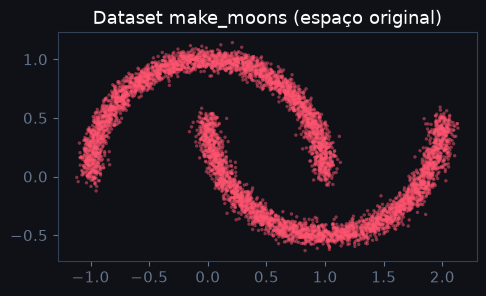

média: [ 0. -0.]  desvio: [1. 1.]


In [2]:
from sklearn.datasets import make_moons

X, _ = make_moons(6000, noise=0.05, random_state=42)
X = X.astype("float32")
mean, std = X.mean(0), X.std(0)
Xn = (X - mean) / std                      # normalização
x0 = torch.tensor(Xn, device=device)

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(X[:, 0], X[:, 1], s=6, c=C_DATA, alpha=.5, edgecolors="none")
ax.set_aspect("equal"); ax.set_title("Dataset make_moons (espaço original)")
plt.tight_layout(); plt.show()
print("média:", Xn.mean(0).round(3), " desvio:", Xn.std(0).round(3))

## 2 · Processo forward — adicionando ruído

A cada passo $t$ injetamos um pouco de ruído gaussiano:

$$q(x_t \mid x_{t-1}) = \mathcal{N}\!\left(x_t;\ \sqrt{1-\beta_t}\,x_{t-1},\ \beta_t I\right)$$

O **noise schedule** $\beta_t$ controla quanto ruído entra em cada passo.
Graças à propriedade de reparametrização, podemos pular direto de $x_0$ para
qualquer $x_t$:

$$x_t = \sqrt{\bar\alpha_t}\,x_0 + \sqrt{1-\bar\alpha_t}\,\epsilon,
\qquad \bar\alpha_t = \prod_{s=1}^{t}(1-\beta_s),\ \ \epsilon\sim\mathcal{N}(0,I)$$

> **Detalhe que importa:** usamos $\beta$ de `1e-4` a `0.02`. Com um schedule
> fraco demais, $\bar\alpha_T$ fica alto e os dados *nunca* viram ruído puro —
> aí a amostragem (que parte de $\mathcal{N}(0,I)$) não tem como funcionar.

In [3]:
T = 400
beta  = torch.linspace(1e-4, 0.02, T, device=device)   # schedule linear (DDPM)
alpha = 1.0 - beta
abar  = torch.cumprod(alpha, 0)

def q_sample(x0, t, eps=None):
    "Amostra x_t diretamente de x_0 (forward em 1 passo)."
    if eps is None:
        eps = torch.randn_like(x0)
    a = abar[t].unsqueeze(1)
    xt = torch.sqrt(a) * x0 + torch.sqrt(1 - a) * eps
    return xt, eps

print(f"abar[0] = {abar[0]:.4f}  ->  x_1 ~ dados")
print(f"abar[-1] = {abar[-1]:.4f}  ->  sqrt = {abar[-1].sqrt():.3f} "
      f"(sinal quase nulo: x_T ~ ruído puro)")

abar[0] = 0.9999  ->  x_1 ~ dados
abar[-1] = 0.0175  ->  sqrt = 0.132 (sinal quase nulo: x_T ~ ruído puro)


Visualizando a corrupção progressiva — os dados derretem em ruído gaussiano:

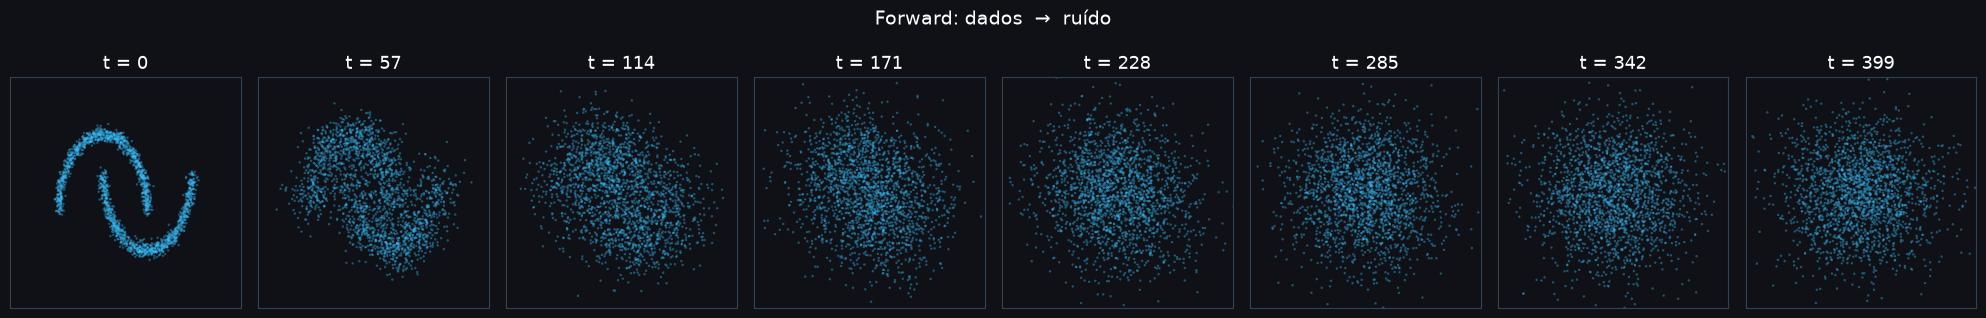

In [4]:
steps = torch.linspace(0, T - 1, 8).long()
fig, axes = plt.subplots(1, 8, figsize=(20, 3))
for ax, tv in zip(axes, steps):
    t = torch.full((2000,), tv, device=device, dtype=torch.long)
    xt, _ = q_sample(x0[:2000], t)
    ax.scatter(xt[:, 0].cpu(), xt[:, 1].cpu(), s=3, c=C_NOISE, alpha=.4, edgecolors="none")
    ax.set(xlim=(-3, 3), ylim=(-3, 3), aspect="equal", xticks=[], yticks=[])
    ax.set_title(f"t = {tv.item()}", color="white")
fig.suptitle("Forward: dados  →  ruído", color="white", y=1.05, fontsize=14)
plt.tight_layout(); plt.show()

## 3 · A rede $\epsilon_\theta(x_t, t)$

A rede recebe um ponto ruidoso $x_t$ e o passo $t$, e **prevê o ruído** $\epsilon$
que foi adicionado. Duas escolhas de projeto fazem diferença mesmo em 2D:

- **Time embedding sinusoidal** (como em Transformers): passar `t/T` como um
  escalar cru é fraco; o embedding dá à rede uma representação rica do passo.
- **Conexões residuais + SiLU:** ajudam o treino a convergir para um erro baixo.

In [5]:
def time_embedding(t, dim=64):
    "Embedding sinusoidal do passo t (igual ao de Transformers)."
    half = dim // 2
    freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device) / (half - 1))
    args = t.float().unsqueeze(1) * freqs.unsqueeze(0)
    return torch.cat([torch.sin(args), torch.cos(args)], dim=1)

class Denoiser(nn.Module):
    def __init__(self, temb=64, h=256):
        super().__init__()
        self.temb  = temb
        self.tproj = nn.Sequential(nn.Linear(temb, h), nn.SiLU(), nn.Linear(h, h))
        self.inp   = nn.Linear(2, h)
        self.b1 = nn.Sequential(nn.SiLU(), nn.Linear(h, h))
        self.b2 = nn.Sequential(nn.SiLU(), nn.Linear(h, h))
        self.b3 = nn.Sequential(nn.SiLU(), nn.Linear(h, h))
        self.out = nn.Linear(h, 2)
    def forward(self, x, t):
        te = self.tproj(time_embedding(t, self.temb))
        h = self.inp(x) + te
        h = h + self.b1(h)
        h = h + self.b2(h + te)
        h = h + self.b3(h)
        return self.out(h)

model = Denoiser().to(device)
print(model)
print("parâmetros:", sum(p.numel() for p in model.parameters()))

Denoiser(
  (tproj): Sequential(
    (0): Linear(in_features=64, out_features=256, bias=True)
    (1): SiLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
  )
  (inp): Linear(in_features=2, out_features=256, bias=True)
  (b1): Sequential(
    (0): SiLU()
    (1): Linear(in_features=256, out_features=256, bias=True)
  )
  (b2): Sequential(
    (0): SiLU()
    (1): Linear(in_features=256, out_features=256, bias=True)
  )
  (b3): Sequential(
    (0): SiLU()
    (1): Linear(in_features=256, out_features=256, bias=True)
  )
  (out): Linear(in_features=256, out_features=2, bias=True)
)
parâmetros: 281090


## 4 · Treinamento

A perda é simplesmente o **MSE entre o ruído real e o previsto** (Ho et al., 2020):

$$\mathcal{L} = \mathbb{E}_{t,\,x_0,\,\epsilon}
\left[\ \big\|\ \epsilon - \epsilon_\theta(\sqrt{\bar\alpha_t}\,x_0 +
\sqrt{1-\bar\alpha_t}\,\epsilon,\ t)\ \big\|^2\ \right]$$

Sorteamos $t$ e $\epsilon$, corrompemos $x_0$, e punimos o erro na previsão do ruído.
Nada de discriminadores ou likelihoods complicadas — puro MSE.

step     0   loss 1.2484


step  1000   loss 0.4413


step  2000   loss 0.3443


step  3000   loss 0.3733


step  4000   loss 0.3620


step  5000   loss 0.3565


step  6000   loss 0.2967


step  7000   loss 0.3786


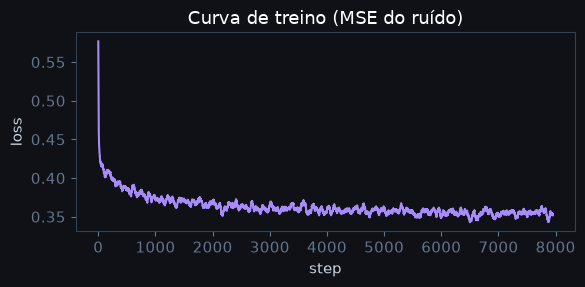

In [6]:
opt   = torch.optim.Adam(model.parameters(), lr=2e-3)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, 8000)

losses = []
model.train()
for step in range(8000):
    idx = torch.randint(0, len(x0), (512,), device=device)
    t   = torch.randint(0, T, (512,), device=device)
    xt, eps = q_sample(x0[idx], t)
    loss = ((model(xt, t) - eps) ** 2).mean()
    opt.zero_grad(); loss.backward(); opt.step(); sched.step()
    losses.append(loss.item())
    if step % 1000 == 0:
        print(f"step {step:5d}   loss {loss.item():.4f}")

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(np.convolve(losses, np.ones(50)/50, "valid"), c=ACC)
ax.set(title="Curva de treino (MSE do ruído)", xlabel="step", ylabel="loss")
plt.tight_layout(); plt.show()

## 5 · Processo reverse — amostragem

Começamos de **ruído puro** $x_T \sim \mathcal{N}(0, I)$ e removemos ruído passo a
passo usando a rede treinada:

$$x_{t-1} = \frac{1}{\sqrt{\alpha_t}}
\left(x_t - \frac{1-\alpha_t}{\sqrt{1-\bar\alpha_t}}\,\epsilon_\theta(x_t, t)\right)
+ \sqrt{\beta_t}\,z, \qquad z \sim \mathcal{N}(0, I)$$

Guardamos a **trajetória** inteira — ela vira o GIF dos slides.

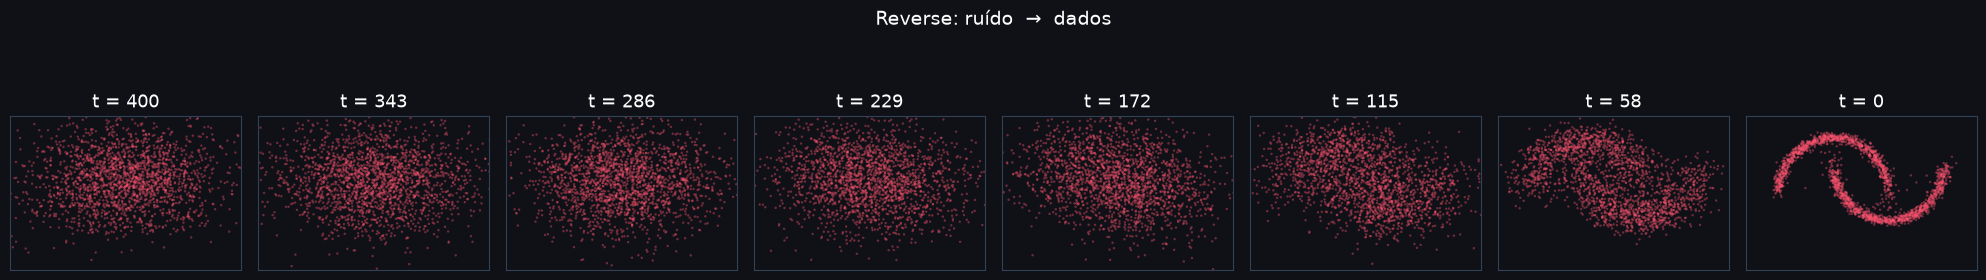

In [7]:
@torch.no_grad()
def sample(n=2000, return_traj=False):
    model.eval()
    x = torch.randn(n, 2, device=device)          # ruído puro
    traj = [x.cpu().numpy()]
    for i in reversed(range(T)):
        t = torch.full((n,), i, device=device, dtype=torch.long)
        eps = model(x, t)
        z = torch.randn_like(x) if i > 0 else torch.zeros_like(x)
        x = (1/torch.sqrt(alpha[i])) * (x - (1-alpha[i])/torch.sqrt(1-abar[i]) * eps) \
            + torch.sqrt(beta[i]) * z
        if return_traj:
            traj.append(x.cpu().numpy())
    return x.cpu().numpy(), traj

s, traj = sample(2000, return_traj=True)
denorm = lambda a: a * std + mean

# reverse: ruído -> dados
idxs = [int(i) for i in np.linspace(0, T, 8)]
fig, axes = plt.subplots(1, 8, figsize=(20, 3))
for ax, k in zip(axes, idxs):
    p = denorm(traj[k])
    ax.scatter(p[:, 0], p[:, 1], s=3, c=C_DATA, alpha=.4, edgecolors="none")
    ax.set(xlim=(-1.6, 2.6), ylim=(-1.4, 1.4), aspect="equal", xticks=[], yticks=[])
    ax.set_title(f"t = {T-k}", color="white")
fig.suptitle("Reverse: ruído  →  dados", color="white", y=1.05, fontsize=14)
plt.tight_layout(); plt.show()

**Comparação final** — a distribuição gerada cobre as duas luas do dataset real:

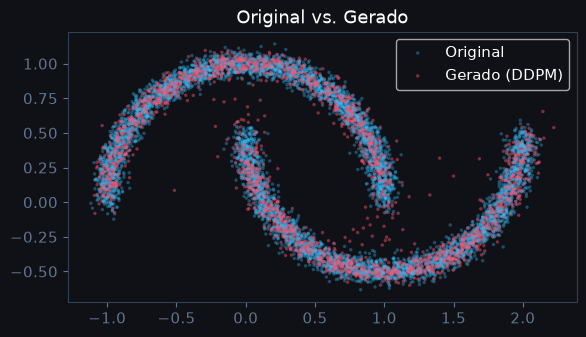

In [8]:
sd = denorm(s)
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X[:, 0], X[:, 1], s=6, c=C_NOISE, alpha=.35, edgecolors="none", label="Original")
ax.scatter(sd[:, 0], sd[:, 1], s=6, c=C_DATA, alpha=.45, edgecolors="none", label="Gerado (DDPM)")
ax.legend(facecolor=BG, labelcolor="white"); ax.set_aspect("equal")
ax.set_title("Original vs. Gerado")
plt.tight_layout(); plt.show()

## 6 · Gerando o GIF para os slides

Animamos a trajetória do *reverse* — os pontos partem do ruído (azul) e se
condensam nas duas luas (rosa). O arquivo é salvo em `../assets/`, de onde o
Slidev o serve para a apresentação.

In [9]:
from PIL import Image

os.makedirs("../assets", exist_ok=True)
frames_idx = np.linspace(0, T, 56).astype(int)   # nº de quadros (GIF leve)
N_GIF = 1400                                      # subconjunto de pontos por quadro

def render(k):
    step = T - k
    prog = 1 - step / T
    p = denorm(traj[k])[:N_GIF]
    fig, ax = plt.subplots(figsize=(6.2, 5.4), dpi=100)
    col = (1 - prog) * np.array([0.22, 0.74, 0.97]) + prog * np.array([1.0, 0.33, 0.44])
    ax.scatter(p[:, 0], p[:, 1], s=9, c=[col], alpha=.55, edgecolors="none")
    ax.set(xlim=(-1.6, 2.6), ylim=(-1.4, 1.4), aspect="equal", xticks=[], yticks=[])
    for sp in ax.spines.values(): sp.set_visible(False)
    ax.set_title(f"Processo reverso  ·  passo t = {step:3d}", color="white",
                 fontsize=15, pad=12, fontweight="bold")
    ax.text(.5, -.06, "ruído gaussiano  →  distribuição dos dados",
            transform=ax.transAxes, ha="center", color="#94a3b8", fontsize=11)
    ax.plot([.15, .85], [-.14, -.14], transform=ax.transAxes, color="#334155", lw=5, solid_capstyle="round")
    ax.plot([.15, .15 + .7*prog], [-.14, -.14], transform=ax.transAxes, color=C_NOISE, lw=5, solid_capstyle="round")
    fig.subplots_adjust(left=.04, right=.96, top=.9, bottom=.16)
    buf = io.BytesIO(); fig.savefig(buf, format="png", facecolor=BG); plt.close(fig)
    buf.seek(0); return Image.open(buf).convert("RGB")

frames = [render(k) for k in frames_idx]
frames += [frames[-1]] * 12                       # segura o quadro final
# paleta adaptativa + optimize => GIF pequeno o bastante para versionar
q = [f.quantize(colors=64, method=Image.MEDIANCUT, dither=Image.NONE) for f in frames]
q[0].save("../assets/reverse_diffusion.gif", save_all=True, append_images=q[1:],
          duration=90, loop=0, optimize=True, disposal=2)
mb = os.path.getsize("../assets/reverse_diffusion.gif") / 1e6
print(f"salvo ../assets/reverse_diffusion.gif — {len(frames)} quadros, {mb:.2f} MB")

salvo ../assets/reverse_diffusion.gif — 68 quadros, 1.72 MB


Também exportamos duas figuras estáticas para os slides (úteis no PDF, onde o GIF não anima):

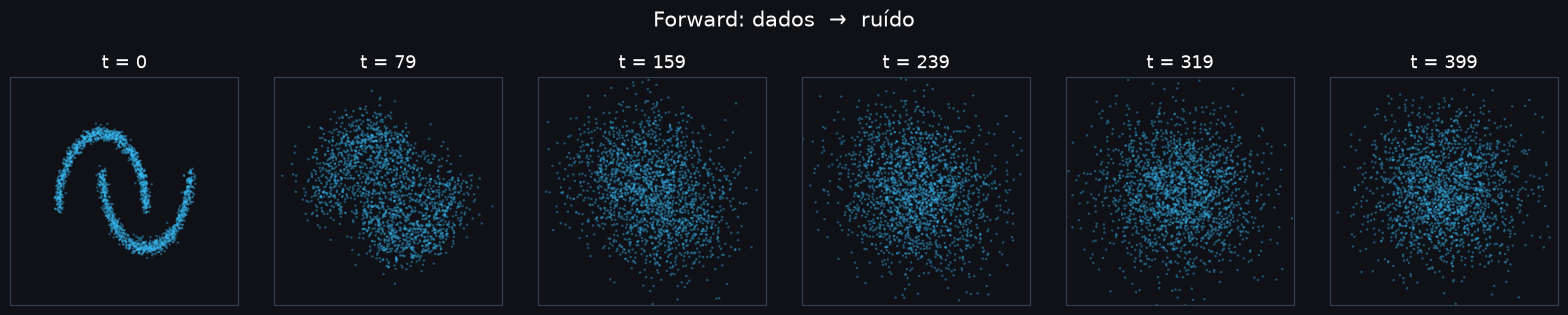

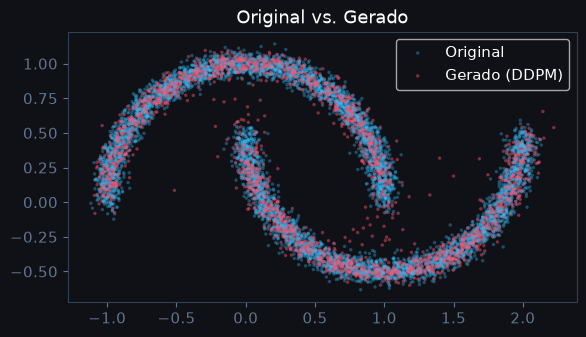

salvos ../assets/forward.png e ../assets/comparison.png


In [10]:
# forward.png — corrupção progressiva
fig, axes = plt.subplots(1, 6, figsize=(16, 3))
for ax, tv in zip(axes, torch.linspace(0, T - 1, 6).long()):
    t = torch.full((2000,), tv, device=device, dtype=torch.long)
    xt, _ = q_sample(x0[:2000], t)
    ax.scatter(xt[:, 0].cpu(), xt[:, 1].cpu(), s=3, c=C_NOISE, alpha=.4, edgecolors="none")
    ax.set(xlim=(-3, 3), ylim=(-3, 3), aspect="equal", xticks=[], yticks=[])
    ax.set_title(f"t = {tv.item()}", color="white")
fig.suptitle("Forward: dados  →  ruído", color="white", y=1.04, fontsize=15)
plt.tight_layout(); fig.savefig("../assets/forward.png", dpi=110, bbox_inches="tight"); plt.show()

# comparison.png — payoff
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X[:, 0], X[:, 1], s=6, c=C_NOISE, alpha=.35, edgecolors="none", label="Original")
ax.scatter(sd[:, 0], sd[:, 1], s=6, c=C_DATA, alpha=.45, edgecolors="none", label="Gerado (DDPM)")
ax.legend(facecolor=BG, labelcolor="white"); ax.set_aspect("equal")
ax.set_title("Original vs. Gerado")
plt.tight_layout(); fig.savefig("../assets/comparison.png", dpi=110, bbox_inches="tight"); plt.show()
print("salvos ../assets/forward.png e ../assets/comparison.png")